In [3]:
import pandas as pd

news_df = pd.read_csv("../data/processed_news.csv")

news_df.head()

,clean_text,label
0,st century wire say ben stein reputable profes...,0
1,washington reuters u president donald trump re...,1
2,reuters puerto rico governor ricardo rossello ...,1
3,monday donald trump embarrassed country accide...,0
4,glasgow scotland reuters u presidential candid...,1


In [4]:
X = news_df["clean_text"]
y = news_df["label"]

print(X.shape)
print(y.shape)

(38582,)
(38582,)


In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [6]:
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

d:\NLP Group 39\venv\Lib\site-packages\huggingface_hub\file_download.py:139: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\rosha\.cache\huggingface\hub\models--bert-base-uncased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [7]:
# Tokenize training and testing text

train_encodings = tokenizer(
    X_train.tolist(),
    truncation=True,
    padding=True,
    max_length=128,
    return_tensors="pt"
)

test_encodings = tokenizer(
    X_test.tolist(),
    truncation=True,
    padding=True,
    max_length=128,
    return_tensors="pt"
)

print("Training input shape:", train_encodings["input_ids"].shape)
print("Testing input shape:", test_encodings["input_ids"].shape)

Training input shape: torch.Size([30865, 128])
Testing input shape: torch.Size([7717, 128])


In [8]:
import torch

class FakeNewsDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels.reset_index(drop=True)

    def __getitem__(self, index):
        item = {
            key: value[index]
            for key, value in self.encodings.items()
        }

        item["labels"] = torch.tensor(
            self.labels.iloc[index],
            dtype=torch.long
        )

        return item

    def __len__(self):
        return len(self.labels)

In [9]:
train_dataset = FakeNewsDataset(
    train_encodings,
    y_train
)

test_dataset = FakeNewsDataset(
    test_encodings,
    y_test
)

print("Training samples:", len(train_dataset))
print("Testing samples:", len(test_dataset))

Training samples: 30865
Testing samples: 7717


In [10]:
from transformers import BertForSequenceClassification

model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
)

print("BERT model loaded successfully!")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BERT model loaded successfully!


In [11]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./bert_results",

    num_train_epochs=2,

    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,

    evaluation_strategy="epoch",

    save_strategy="epoch",

    logging_steps=500,

    load_best_model_at_end=True,

    metric_for_best_model="accuracy",

    greater_is_better=True
)

TypeError: TrainingArguments.__init__() got an unexpected keyword argument 'evaluation_strategy'

In [12]:
import transformers

print(transformers.__version__)

5.14.1


In [13]:
from transformers import TrainingArguments
import inspect

print(inspect.signature(TrainingArguments.__init__))

(self, output_dir: str | None = None, per_device_train_batch_size: int = 8, num_train_epochs: float = 3.0, max_steps: int = -1, learning_rate: float = 5e-05, lr_scheduler_type: transformers.trainer_utils.SchedulerType | str = 'linear', lr_scheduler_kwargs: dict | str | None = None, warmup_steps: float = 0, optim: transformers.training_args.OptimizerNames | str = 'adamw_torch_fused', optim_args: str | None = None, weight_decay: float = 0.0, adam_beta1: float = 0.9, adam_beta2: float = 0.999, adam_epsilon: float = 1e-08, optim_target_modules: None | str | list[str] = None, gradient_accumulation_steps: int = 1, average_tokens_across_devices: bool = True, max_grad_norm: float = 1.0, label_smoothing_factor: float = 0.0, bf16: bool = False, fp16: bool = False, bf16_full_eval: bool = False, fp16_full_eval: bool = False, tf32: bool | None = None, gradient_checkpointing: bool = False, gradient_checkpointing_kwargs: dict[str, typing.Any] | str | None = None, torch_compile: bool = False, torch_co

In [14]:
from transformers import __version__
print(__version__)

5.14.1


In [15]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./bert_results",

    num_train_epochs=2,

    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,

    gradient_accumulation_steps=4,

    eval_strategy="epoch",
    save_strategy="epoch",

    logging_steps=500,

    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True,

    save_total_limit=1,

    report_to="none",

    use_cpu=True
)

print("Training arguments created successfully!")

Training arguments created successfully!


In [16]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="binary",
        zero_division=0
    )

    accuracy = accuracy_score(labels, predictions)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [17]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

print("Trainer created successfully!")

Trainer created successfully!


In [18]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.040097,0.013175,0.998704,0.999056,0.998584,0.998820
2,0.021487,0.009628,0.999093,0.999292,0.999056,0.999174


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.atte

TrainOutput(global_step=7718, training_loss=0.048433115278679835, metrics={'train_runtime': 76297.7941, 'train_samples_per_second': 0.809, 'train_steps_per_second': 0.101, 'total_flos': 4060461361843200.0, 'train_loss': 0.048433115278679835, 'epoch': 2.0})

In [19]:
results = trainer.evaluate()

print(results)

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.021487,0.009628,2,0.999093,0.999292,0.999056,0.999174


{'eval_loss': 0.009627900086343288, 'eval_accuracy': 0.999092911753272, 'eval_precision': 0.999291951852726, 'eval_recall': 0.999056158565361, 'eval_f1': 0.9991740412979351}


In [20]:
predictions = trainer.predict(test_dataset)

In [21]:
y_pred = predictions.predictions.argmax(axis=1)

In [22]:
from sklearn.metrics import classification_report, confusion_matrix

print("Classification Report:\n")
print(classification_report(y_test, y_pred))

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3479
           1       1.00      1.00      1.00      4238

    accuracy                           1.00      7717
   macro avg       1.00      1.00      1.00      7717
weighted avg       1.00      1.00      1.00      7717



In [23]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[3476    3]
 [   4 4234]]


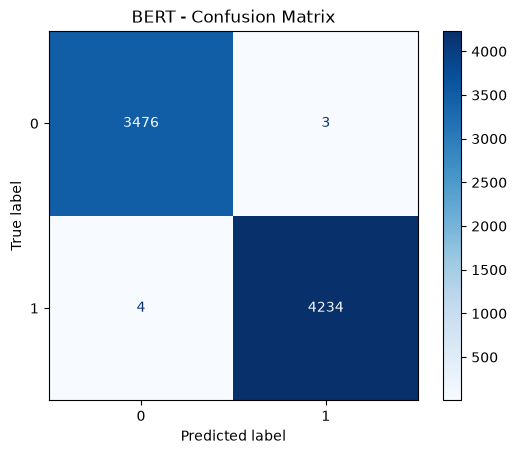

In [24]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Blues")

plt.title("BERT - Confusion Matrix")

plt.show()